# YOLOv11 Keypoint Detection Finetuning

Finetuning YOLOv11, following reference: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolov8-keypoint.ipynb

In [8]:
!pip -V

pip 25.3 from /Users/rjunw/Desktop/dev/nba2nba/.venv/lib/python3.11/site-packages/pip (python 3.11)


## Imports + Installs

In [ ]:
# sys deps
import os
from pathlib import Path
from dotenv import load_dotenv

# data deps
import cv2
import matplotlib.pyplot as plt
import numpy as np
from roboflow import Roboflow
from PIL import Image
from court import Court

# model deps
import supervision as sv
from ultralytics import YOLO

# tracking deps
import mlflow
from tqdm import tqdm

# env vars
load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

# model vars
LOAD_MODEL = True
YOLOv11x_CHECKPOINT = "../models/weights/yolov11x_kpd/checkpoint_best_total.pt"

# mlflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

## Data Processing

In [10]:
CACHE_DIR = Path("../data/.cache/")
CACHE_DIR.mkdir(parents=True,exist_ok=True)

train_data_path = CACHE_DIR.joinpath("bball_court_kpd/")
print('NBA COURT DETECTION DATA:', train_data_path)

# check if we have files in the directory and use them if we do
if list(train_data_path.glob("*")):
    print(f"Data cached, using {train_data_path}")

# otherwise download from Roboflow
else:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("roboflow-jvuqo").project("basketball-court-detection-2")
    version = project.version(19)
    dataset = version.download("yolov8", location=str(train_data_path))

NBA COURT DETECTION DATA: ../data/.cache/bball_court_kpd
Data cached, using ../data/.cache/bball_court_kpd


## NBA Court Keypoint Detection Finetuning

YOLOv11 has it's own formatting to use (not COCO). You can download the Roboflow dataset directly in YOLOv8 format and train, or you can use ultralytics JSON2YOLO to convert COCO format to YOLO.

In [11]:
train_config = {
    "epochs": 300,
    "imgsz": 640
}

if LOAD_MODEL and Path(YOLOv11x_CHECKPOINT).is_file():
    print("Loading model from checkpoint weights")
    model = YOLO(YOLOv11x_CHECKPOINT, task='pose')
else:
    mlflow.set_experiment("yolov11_kpd_finetuning")
    print("Finetuning model from COCO pre-trained weights")

    with mlflow.start_run(run_name="yolov11_kpd_finetuning"):
        mlflow.log_params(train_config)
        model = YOLO("yolo11x-pose.pt")
        os.rename("yolo11x-pose.pt", "../models/weights/yolov11x_kpd/yolo11x-pose.pt")
        model.train(
            dataset_dir=str(train_data_path) + "/data.yaml",
            **train_config
        )

    mlflow.end_run()

Loading model from checkpoint weights


## Evaluating Fine-Tuned YOLOv11

Because the data edges are unlabeled, I'll be manually looking through the keypoints detected and building an edgelist to label the edges.

### Building Keypoint Edge Visualization List


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/indiana-pacers-new-york-knicks-game-3-q1-07_10-07_03_mp4-0007_jpg.rf.6cadd8a7725d488221e29fc51a7881c9.jpg: 640x640 1 court, 380.6ms
Speed: 6.4ms preprocess, 380.6ms inference, 9.2ms postprocess per image at shape (1, 3, 640, 640)
Keeping 12 out of 33
Filtered KP IDs: [18 19 21 22 23 24 25 26 27 28 29 30]


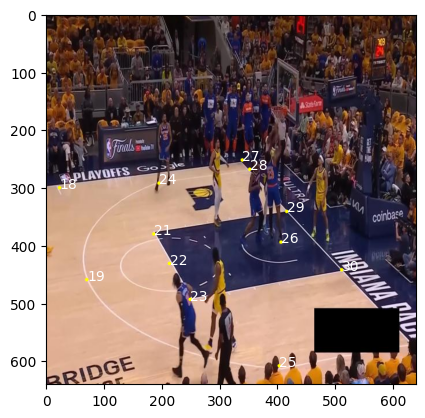


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/new-york-knicks-detroit-pistons-game-4-q2-10_53-10_44_mp4-0002_jpg.rf.77d4c380281e564016f5bd5c180b6dc6.jpg: 640x640 1 court, 376.6ms
Speed: 0.9ms preprocess, 376.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Keeping 11 out of 33
Filtered KP IDs: [ 0  1  2  3  6  7  9 10 11 12 13]


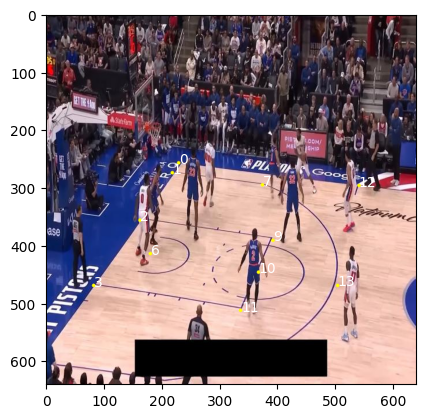


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/new-york-knicks-detroit-pistons-game-4-q1-04_32-04_24_mp4-0005_jpg.rf.7accabb3e90cf2daa2c30a1b0089547a.jpg: 640x640 1 court, 474.4ms
Speed: 1.0ms preprocess, 474.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/los-angeles-lakers-minnesota-timberwolve-game-3-q1-11_50-11_43_mp4-0001_jpg.rf.9d9889b17250e5db645efed07af32450.jpg: 640x640 1 court, 307.7ms
Speed: 0.8ms preprocess, 307.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Keeping 12 out of 33
Filtered KP IDs: [ 0  1  2  3  6  7  8  9 10 11 12 13]


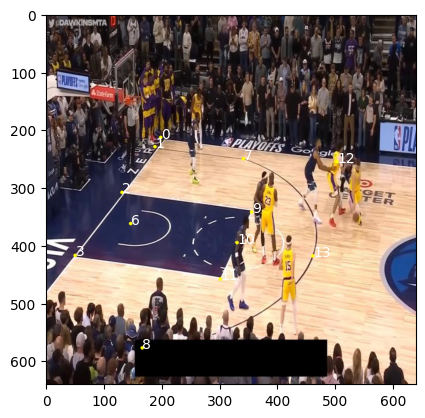


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/new-york-knicks-detroit-pistons-game-4-q1-00_31-00_09_mp4-0007_jpg.rf.cb66b90dc2ad0ef9fd5c55c833337d3a.jpg: 640x640 1 court, 358.3ms
Speed: 0.9ms preprocess, 358.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/indiana-pacers-milwaukee-bucks-game-4-q1-11_18-11_15_mp4-0001_jpg.rf.c958a827ff6028e38dd5035685fbe330.jpg: 640x640 1 court, 332.4ms
Speed: 0.8ms preprocess, 332.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/boston-celtics-orlando-magic-game-4-q1-07_16-07_10_mp4-0001_jpg.rf.941fc36bfc553da58a875637767580de.jpg: 640x640 1 court, 320.2ms
Speed: 0.8ms preprocess, 320.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/rj

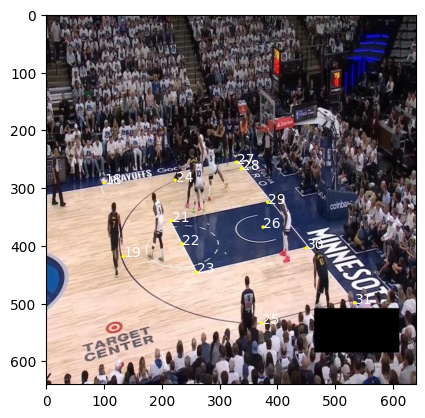


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/oklahoma-city-thunder-memphis-grizzlies-game-4-q1-08_41-08_34_mp4-0001_jpg.rf.be597916e6a8b85e599dbf9044048a0c.jpg: 640x640 1 court, 330.7ms
Speed: 0.9ms preprocess, 330.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/minnesota-timberwolves-oklahoma-city-thunder-game-1-1-q3-01_14-01_08_mp4-0000_jpg.rf.b6ee296f74ab18c57f21510f96f6abac.jpg: 640x640 1 court, 311.1ms
Speed: 0.8ms preprocess, 311.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Keeping 8 out of 33
Filtered KP IDs: [ 7  9 10 11 12 13 15 16]


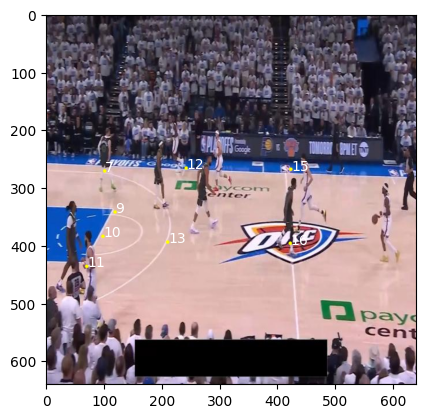

In [12]:
# testing evaluation
seen_kp_ids = set()
for i in range(10):

    # pick a test image
    random_file = os.listdir(f"{str(train_data_path)}/test/images")[i]
    file_name = os.path.join(f"{str(train_data_path)}/test/images", random_file)

    # kpd using trained model 
    results = model(file_name)

    # get kp object via supervision
    key_points = sv.KeyPoints.from_ultralytics(results[0])

    # filter out low confidence key points
    kp_to_keep = key_points.confidence > 0.5

    # build a filtered key point object
    kp_ids = np.array([i for i in range(key_points.confidence.shape[1])])[kp_to_keep.flatten()]
    if set(kp_ids).issubset(seen_kp_ids):
        continue
    seen_kp_ids.update(kp_ids)

    kp_thresholded = key_points.xy[kp_to_keep]
    kp_confidence_thresholded = key_points.confidence[kp_to_keep]
    thresholded_key_points = sv.KeyPoints(
        xy=kp_thresholded.reshape(-1,*kp_thresholded.shape),
        class_id=key_points.class_id,
        confidence=kp_confidence_thresholded.reshape(-1,*kp_confidence_thresholded.shape)
    )

    print(f"Keeping {len(kp_thresholded)} out of {key_points.xy.shape[1]}")
    print(f"Filtered KP IDs: {kp_ids}")
    
    # just plotting stuff
    annotated_frame = cv2.imread(file_name)

    # annotate keypoints
    vertex_annotator = sv.VertexAnnotator(radius=3, color=sv.Color.YELLOW)
    annotated_frame = vertex_annotator.annotate(
        scene=annotated_frame,
        key_points=thresholded_key_points)

    annotated_frame = sv.resize_image(
        annotated_frame,
        resolution_wh=(640, 640), # keep same as model input size for easier viz
        keep_aspect_ratio=False
    )

    # convert to RGB
    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.imshow(annotated_frame)
    # let's actually label each keypoint so i can make an edge-list mapping
    reshaped_xy = thresholded_key_points.xy.reshape(-1, 2)
    for i in range(len(kp_ids)):
        xy = reshaped_xy[i]
        plt.text(xy[0], xy[1], str(kp_ids[i]), color='white')
    plt.show()

    if len(seen_kp_ids) == 33:
        break



image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/indiana-pacers-new-york-knicks-game-3-q1-07_10-07_03_mp4-0007_jpg.rf.6cadd8a7725d488221e29fc51a7881c9.jpg: 640x640 1 court, 440.5ms
Speed: 1.3ms preprocess, 440.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Keeping 12 out of 33
Filtered KP IDs: [18 19 21 22 23 24 25 26 27 28 29 30]


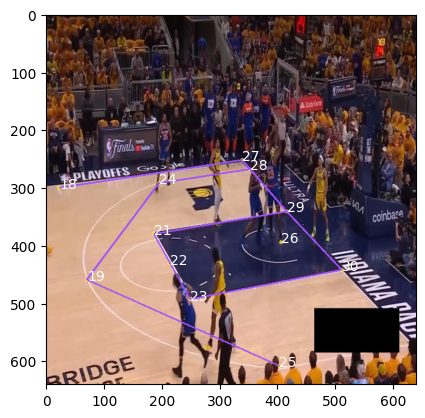


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/new-york-knicks-detroit-pistons-game-4-q2-10_53-10_44_mp4-0002_jpg.rf.77d4c380281e564016f5bd5c180b6dc6.jpg: 640x640 1 court, 330.7ms
Speed: 0.9ms preprocess, 330.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Keeping 11 out of 33
Filtered KP IDs: [ 0  1  2  3  6  7  9 10 11 12 13]


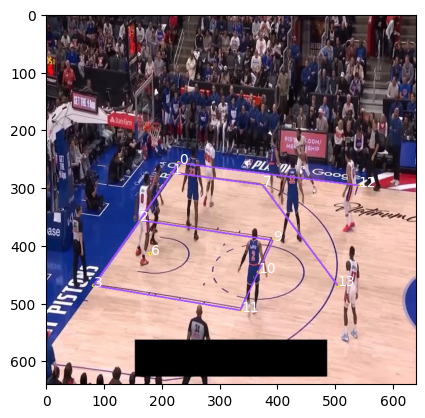


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/new-york-knicks-detroit-pistons-game-4-q1-04_32-04_24_mp4-0005_jpg.rf.7accabb3e90cf2daa2c30a1b0089547a.jpg: 640x640 1 court, 324.5ms
Speed: 0.9ms preprocess, 324.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Keeping 12 out of 33
Filtered KP IDs: [18 19 21 22 23 24 25 26 27 28 29 30]


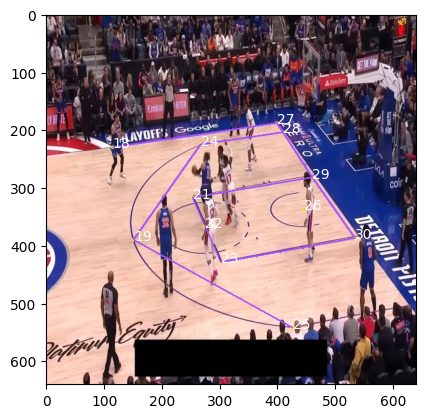


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/los-angeles-lakers-minnesota-timberwolve-game-3-q1-11_50-11_43_mp4-0001_jpg.rf.9d9889b17250e5db645efed07af32450.jpg: 640x640 1 court, 400.3ms
Speed: 1.1ms preprocess, 400.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Keeping 12 out of 33
Filtered KP IDs: [ 0  1  2  3  6  7  8  9 10 11 12 13]


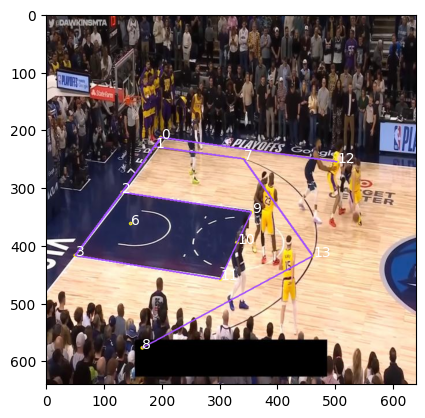


image 1/1 /Users/rjunw/Desktop/dev/nba2nba/notebooks/../data/.cache/bball_court_kpd/test/images/new-york-knicks-detroit-pistons-game-4-q1-00_31-00_09_mp4-0007_jpg.rf.cb66b90dc2ad0ef9fd5c55c833337d3a.jpg: 640x640 1 court, 361.5ms
Speed: 0.8ms preprocess, 361.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Keeping 10 out of 33
Filtered KP IDs: [19 21 22 23 24 26 27 28 29 30]


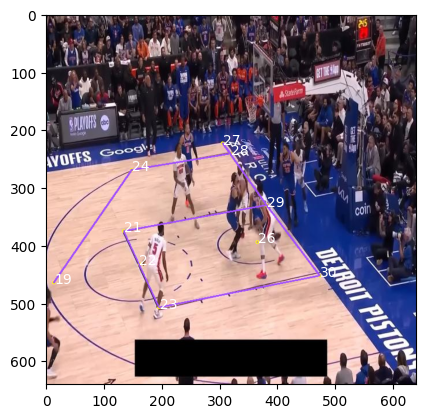

In [13]:
for i in range(5):
    image_court = Court()
    # pick a test image
    random_file = os.listdir(f"{str(train_data_path)}/test/images")[i]
    file_name = os.path.join(f"{str(train_data_path)}/test/images", random_file)

    # kpd using trained model 
    results = model(file_name)

    # get kp object via supervision
    key_points = sv.KeyPoints.from_ultralytics(results[0])

    # filter out low confidence key points
    kp_to_keep = key_points.confidence > 0.5

    # build a filtered key point object
    kp_ids = np.array([i for i in range(key_points.confidence.shape[1])])[kp_to_keep.flatten()]

    # filter down edge list to what we have
    image_court.kp_edge_list = [(edge[0]+1, edge[1]+1) for edge in image_court.kp_edge_list if edge[0] in set(kp_ids) and edge[1] in set(kp_ids)]

    kp_thresholded = key_points.xy[kp_to_keep]
    kp_confidence_thresholded = key_points.confidence[kp_to_keep]
    thresholded_key_points = sv.KeyPoints(
        xy=kp_thresholded.reshape(-1,*kp_thresholded.shape),
        class_id=key_points.class_id,
        confidence=kp_confidence_thresholded.reshape(-1,*kp_confidence_thresholded.shape)
    )

    print(f"Keeping {len(kp_thresholded)} out of {key_points.xy.shape[1]}")
    print(f"Filtered KP IDs: {kp_ids}")

    # just plotting stuff
    annotated_frame = cv2.imread(file_name)

    # annotate keypoints
    vertex_annotator = sv.VertexAnnotator(radius=3, color=sv.Color.YELLOW)
    annotated_frame = vertex_annotator.annotate(
        scene=annotated_frame,
        key_points=thresholded_key_points)

    # annotate edges
    edge_annotator = sv.EdgeAnnotator(thickness=2, edges=image_court.kp_edge_list)
    annotated_frame = edge_annotator.annotate(
        scene=annotated_frame,
        key_points=key_points)

    annotated_frame = sv.resize_image(
        annotated_frame,
        resolution_wh=(640, 640), # keep same as model input size for easier viz
        keep_aspect_ratio=True
    )

    # convert to RGB
    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.imshow(annotated_frame)
    # let's actually label each keypoint so i can make an edge-list mapping
    reshaped_xy = thresholded_key_points.xy.reshape(-1, 2)
    for i in range(len(kp_ids)):
        xy = reshaped_xy[i]
        plt.text(xy[0], xy[1], str(kp_ids[i]), color='white')
    plt.show()

In `court.py`, I've defined the overall court geometry with ids matching the keypoint labels.

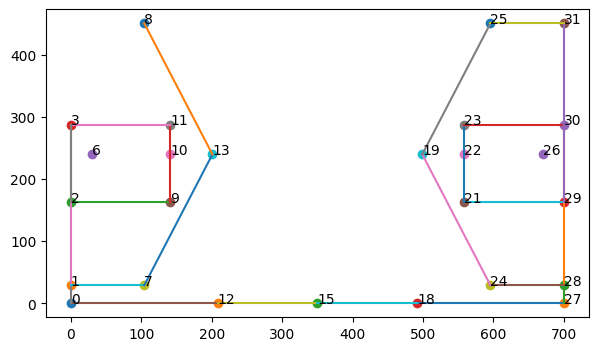

In [36]:
W, H = 700, 480
plt.figure(figsize=(W//100, H//100))
ball_court = Court(width=W, height = H)
for idx, coord in ball_court.kp_coordinates.items():
    plt.scatter(coord[0], coord[1])
    plt.text(coord[0], coord[1], idx)
for edge in ball_court.kp_edge_list:
    plt.plot([ball_court.kp_coordinates[edge[0]][0], ball_court.kp_coordinates[edge[1]][0]], [ball_court.kp_coordinates[edge[0]][1], ball_court.kp_coordinates[edge[1]][1]])

plt.show()